In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [2]:
x1, x2, x3, x4 = sp.symbols('x1 x2 x3 x4')
lam1, lam2 = sp.symbols('lam1 lam2')

# ***Sceanrio 1***

# **Lagrange Multiplier**

define the Objective (Inefficiency) Function

In [3]:
I = (
    0.04*x1**2
    + 0.06*x2**2
    + 0.05*x3**2
    + 0.03*x4**2
    - 0.02*x1*x2
    + x1 - x2
    + 0.5*x3
    + 0.3*x4
)


Define Equality Constraints

In [4]:
g1 = x1 + x2 - 50
g2 = x3 + x4 - 60

Construct the Lagrangian

In [6]:
L = I + lam1 * g1 + lam2 * g2

Compute Partial Derivatives

In [7]:
eq1 = sp.diff(L, x1)
eq2 = sp.diff(L, x2)
eq3 = sp.diff(L, x3)
eq4 = sp.diff(L, x4)
eq5 = sp.diff(L, lam1)
eq6 = sp.diff(L, lam2)

Solve the System of Equations

In [8]:
solution = sp.solve(
    [eq1, eq2, eq3, eq4, eq5, eq6],
    [x1, x2, x3, x4, lam1, lam2],
    dict=True
)

solution


[{lam1: -2.08333333333333,
  lam2: -2.62500000000000,
  x1: 20.8333333333333,
  x2: 29.1666666666667,
  x3: 21.2500000000000,
  x4: 38.7500000000000}]

Extract the Optimal Solution

In [9]:
opt_solution = solution[0]

x1_opt = float(opt_solution[x1])
x2_opt = float(opt_solution[x2])
x3_opt = float(opt_solution[x3])
x4_opt = float(opt_solution[x4])


Compute the Best Fitness (Minimum Inefficiency)

In [10]:
best_fitness = I.subs({
    x1: x1_opt,
    x2: x2_opt,
    x3: x3_opt,
    x4: x4_opt
})

best_fitness = float(best_fitness)


Results

In [12]:
print("Optimal Weekly Distribution (tons):")
print(f"Amman (x1): {x1_opt:.3f}")
print(f"Zarqa (x2): {x2_opt:.3f}")
print(f"Irbid (x3): {x3_opt:.3f}")
print(f"Aqaba (x4): {x4_opt:.3f}")

print("Best Fitness (Minimum Inefficiency):")
print(f"I = {best_fitness:.4f}")


Optimal Weekly Distribution (tons):
Amman (x1): 20.833
Zarqa (x2): 29.167
Irbid (x3): 21.250
Aqaba (x4): 38.750
Best Fitness (Minimum Inefficiency):
I = 137.7917


Inefficiency vs Amman & Zarqa

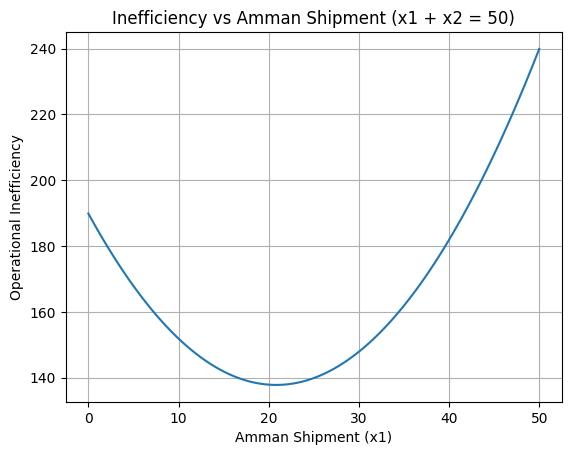

In [13]:
x1_vals = np.linspace(0, 50, 100)
x2_vals = 50 - x1_vals

I_vals = [
    0.04*x1**2 + 0.06*x2**2 - 0.02*x1*x2 + x1 - x2
    + 0.05*x3_opt**2 + 0.03*x4_opt**2
    + 0.5*x3_opt + 0.3*x4_opt
    for x1, x2 in zip(x1_vals, x2_vals)
]

plt.figure()
plt.plot(x1_vals, I_vals)
plt.xlabel("Amman Shipment (x1)")
plt.ylabel("Operational Inefficiency")
plt.title("Inefficiency vs Amman Shipment (x1 + x2 = 50)")
plt.grid(True)
plt.show()


Inefficiency vs Irbid & Aqaba

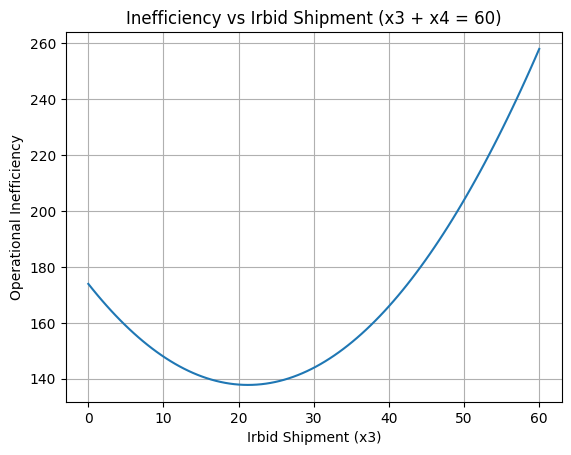

In [14]:
x3_vals = np.linspace(0, 60, 100)
x4_vals = 60 - x3_vals
I_vals_2 = [
    0.04*x1_opt**2 + 0.06*x2_opt**2 - 0.02*x1_opt*x2_opt
    + x1_opt - x2_opt
    + 0.05*x3**2 + 0.03*x4**2
    + 0.5*x3 + 0.3*x4
    for x3, x4 in zip(x3_vals, x4_vals)
]

plt.figure()
plt.plot(x3_vals, I_vals_2)
plt.xlabel("Irbid Shipment (x3)")
plt.ylabel("Operational Inefficiency")
plt.title("Inefficiency vs Irbid Shipment (x3 + x4 = 60)")
plt.grid(True)
plt.show()


# **KKT**

Define decision variables and multipliers

In [31]:
x1, x2, x3, x4 = sp.symbols('x1 x2 x3 x4')
lam1, lam2 = sp.symbols('lam1 lam2')

Define objective function (inefficiency)

In [32]:
I = (
    0.04*x1**2
    + 0.06*x2**2
    + 0.05*x3**2
    + 0.03*x4**2
    - 0.02*x1*x2
    + x1 - x2
    + 0.5*x3
    + 0.3*x4
)


Define equality constraints

In [33]:
g1 = x1 + x2 - 50
g2 = x3 + x4 - 60

KKT framework

In [34]:
L = I + lam1*g1 + lam2*g2

Compute partial derivatives

In [35]:
eq1 = sp.diff(L, x1)
eq2 = sp.diff(L, x2)
eq3 = sp.diff(L, x3)
eq4 = sp.diff(L, x4)
eq5 = sp.diff(L, lam1)
eq6 = sp.diff(L, lam2)

Solve KKT system

In [36]:
solution = sp.solve(
    [eq1, eq2, eq3, eq4, eq5, eq6],
    [x1, x2, x3, x4, lam1, lam2]
)

In [44]:
print("\nOptimal Decision Variables:")
print("x1 =", x1_opt)
print("x2 =", x2_opt)
print("x3 =", x3_opt)
print("x4 =", x4_opt)



Optimal Decision Variables:
x1 = 20.8333333333333
x2 = 29.1666666666667
x3 = 21.25
x4 = 38.75


In [45]:
I_star = I.subs({
    x1: x1_opt,
    x2: x2_opt,
    x3: x3_opt,
    x4: x4_opt
})

print("\nOptimal Inefficiency Value:")
print(I_star)



Optimal Inefficiency Value:
137.791666666667


Soluiton

Extract optimal decision variables

In [46]:
x3_opt = 21.25
x4_opt = 38.75


In [47]:
x1 = np.linspace(0, 50, 100)
x2 = np.linspace(0, 50, 100)

X1, X2 = np.meshgrid(x1, x2)


In [48]:
Z = (
    0.04 * X1**2
    + 0.06 * X2**2
    - 0.02 * X1 * X2
    + X1
    - X2
    + 0.05 * x3_opt**2
    + 0.03 * x4_opt**2
    + 0.5 * x3_opt
    + 0.3 * x4_opt
)


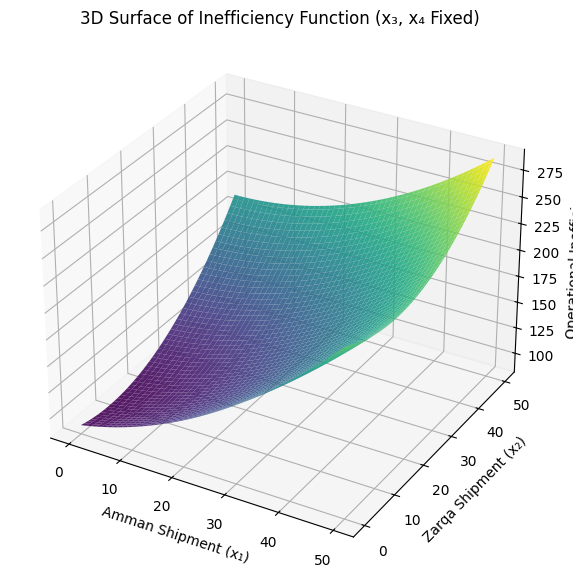

In [49]:
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.9)

ax.set_xlabel("Amman Shipment (x₁)")
ax.set_ylabel("Zarqa Shipment (x₂)")
ax.set_zlabel("Operational Inefficiency")

ax.set_title("3D Surface of Inefficiency Function (x₃, x₄ Fixed)")

plt.show()


# **gradint**

In [51]:
x1, x2, x3, x4 = sp.symbols('x1 x2 x3 x4')


Compute the Gradient

In [52]:
grad_I = sp.Matrix([
    sp.diff(I, x1),
    sp.diff(I, x2),
    sp.diff(I, x3),
    sp.diff(I, x4)
])

print("Gradient of the objective function:")
grad_I

Gradient of the objective function:


Matrix([
[ 0.08*x1 - 0.02*x2 + 1],
[-0.02*x1 + 0.12*x2 - 1],
[          0.1*x3 + 0.5],
[         0.06*x4 + 0.3]])

Solve for stationary point

In [53]:
critical_point = sp.solve(
    grad_I,
    [x1, x2, x3, x4]
)

print("Unconstrained Critical Point:")
critical_point


Unconstrained Critical Point:


{x1: -10.8695652173913,
 x2: 6.52173913043478,
 x3: -5.00000000000000,
 x4: -5.00000000000000}

Compute the Hessian Matrix

In [54]:
Hessian_I = sp.hessian(I, (x1, x2, x3, x4))

print("Hessian Matrix:")
Hessian_I


Hessian Matrix:


Matrix([
[ 0.08, -0.02,   0,    0],
[-0.02,  0.12,   0,    0],
[    0,     0, 0.1,    0],
[    0,     0,   0, 0.06]])

Check Convexity Using Hessian Eigenvalues

In [55]:
eigenvals = Hessian_I.eigenvals()

print("Eigenvalues of the Hessian:")
eigenvals

Eigenvalues of the Hessian:


{0.0717157287525381: 1,
 0.128284271247462: 1,
 0.100000000000000: 1,
 0.0600000000000000: 1}

Evaluate Objective Value at Unconstrained Optimum

In [56]:
x1_uc = critical_point[x1]
x2_uc = critical_point[x2]
x3_uc = critical_point[x3]
x4_uc = critical_point[x4]

I_uc = I.subs({
    x1: x1_uc,
    x2: x2_uc,
    x3: x3_uc,
    x4: x4_uc
})

print("Unconstrained Optimal Decision Variables:")
print("x1 =", x1_uc)
print("x2 =", x2_uc)
print("x3 =", x3_uc)
print("x4 =", x4_uc)

print("\nUnconstrained Minimum Inefficiency:")
print(I_uc)


Unconstrained Optimal Decision Variables:
x1 = -10.8695652173913
x2 = 6.52173913043478
x3 = -5.00000000000000
x4 = -5.00000000000000

Unconstrained Minimum Inefficiency:
-10.6956521739130


# **Gradient Descent**

Convert symbolic gradient to numerical function

In [57]:

grad_func = sp.lambdify((x1, x2, x3, x4), grad_I, "numpy")

# Gradient Descent parameters
alpha = 0.01
iterations = 50

# Initial guess
x = np.array([0.0, 0.0, 0.0, 0.0])

# Store history
history_gd = []

for _ in range(iterations):
    grad_val = np.array(grad_func(*x), dtype=float).flatten()
    x = x - alpha * grad_val
    history_gd.append(x.copy())

print("Gradient Descent Final Solution:")
print(x)

Gradient Descent Final Solution:
[-0.48795886  0.48321285 -0.24397186 -0.14781602]


In [61]:
x1_gd, x2_gd, x3_gd, x4_gd = x

I_gd = I.subs({
    x1: x1_gd,
    x2: x2_gd,
    x3: x3_gd,
    x4: x4_gd
})

print("Objective Value (Gradient Descent):")
print(I_gd)


Objective Value (Gradient Descent):
-1.10562125125776


# **Newton’s Method **




In [58]:
# Convert Hessian to numerical function
hessian_func = sp.lambdify((x1, x2, x3, x4), Hessian_I, "numpy")

# Initial guess
x_newton = np.array([0.0, 0.0, 0.0, 0.0])

# Newton iteration (1–2 iterations are enough for quadratic)
for _ in range(2):
    grad_val = np.array(grad_func(*x_newton), dtype=float).flatten()
    hess_val = np.array(hessian_func(*x_newton), dtype=float)
    x_newton = x_newton - np.linalg.inv(hess_val) @ grad_val

print("Newton's Method Solution:")
print(x_newton)


Newton's Method Solution:
[-10.86956522   6.52173913  -5.          -5.        ]


In [63]:
# Extract Newton solution
x1_n, x2_n, x3_n, x4_n = x_newton

I_newton = I.subs({
    x1: x1_n,
    x2: x2_n,
    x3: x3_n,
    x4: x4_n
})

print("Objective Value (Newton's Method):")
print(I_newton)


Objective Value (Newton's Method):
-10.6956521739130


compare between unconstrained solution

In [59]:
print("Analytical Unconstrained Solution:")
print([x1_uc, x2_uc, x3_uc, x4_uc])

print("\nGradient Descent Solution:")
print(x)

print("\nNewton Method Solution:")
print(x_newton)


Analytical Unconstrained Solution:
[-10.8695652173913, 6.52173913043478, -5.00000000000000, -5.00000000000000]

Gradient Descent Solution:
[-0.48795886  0.48321285 -0.24397186 -0.14781602]

Newton Method Solution:
[-10.86956522   6.52173913  -5.          -5.        ]


convergence plots foe the unconstrained solutions

In [64]:
# Convert objective function to numerical form
I_func = sp.lambdify((x1, x2, x3, x4), I, "numpy")


In [65]:
# Gradient function already defined as grad_func

alpha = 0.01
iterations = 50

# Initial point
x_gd = np.array([0.0, 0.0, 0.0, 0.0])

gd_values = []

for _ in range(iterations):
    I_val = I_func(*x_gd)
    gd_values.append(I_val)

    grad_val = np.array(grad_func(*x_gd), dtype=float).flatten()
    x_gd = x_gd - alpha * grad_val

print("Final Gradient Descent Solution:")
print(x_gd)


Final Gradient Descent Solution:
[-0.48795886  0.48321285 -0.24397186 -0.14781602]


In [ ]:

x_newton = np.array([0.0, 0.0, 0.0, 0.0])

newton_values = []

for _ in range(5):  # few iterations are enougx_newton)
    newton_values.append(I_val)

    grad_val = np.array(grad_func(*x_newton), dtype=float).flatten()
    hess_val = np.array(hessian_func(*x_newton), dtype=float)
    x_newton = x_newton - np.linalg.inv(hess_val) @ grad_val

print("Final Newton Solution:")
print(x_newton)


Final Newton Solution:
[-10.86956522   6.52173913  -5.          -5.        ]


In [67]:
# Analytical unconstrained optimum (already computed earlier)
I_analytical = float(I_func(x1_uc, x2_uc, x3_uc, x4_uc))

print("Analytical Unconstrained Objective Value:")
print(I_analytical)


Analytical Unconstrained Objective Value:
-10.695652173913043


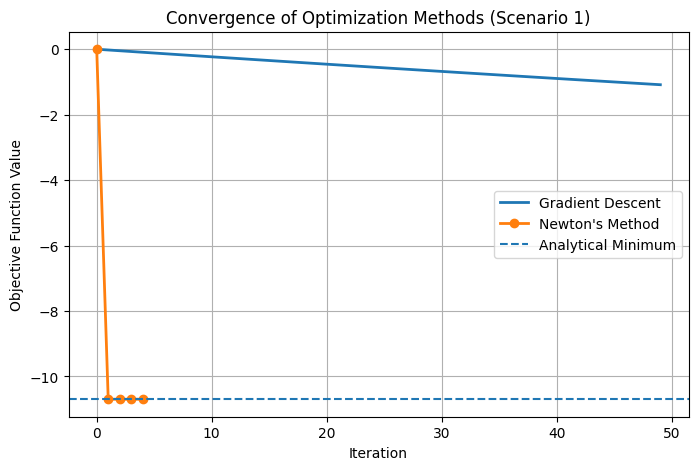

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(gd_values, label="Gradient Descent", linewidth=2)
plt.plot(newton_values, label="Newton's Method", linewidth=2, marker='o')

plt.axhline(
    y=I_analytical,
    linestyle="--",
    label="Analytical Minimum"
)

plt.xlabel("Iteration")
plt.ylabel("Objective Function Value")
plt.title("Convergence of Optimization Methods (Scenario 1)")
plt.legend()
plt.grid(True)
plt.show()


# ***sceanrio 2***

# **grafients**

generate small dataset

In [69]:
np.random.seed(42)

n_samples = 50
X = np.random.rand(n_samples, 5)
true_theta = np.array([2, 1.5, -2, 0.5, 3, -1])

X_bias = np.c_[np.ones(n_samples), X]

y = X_bias @ true_theta + np.random.normal(0, 0.5, n_samples)


Define Cost Function and Gradient

In [70]:
def cost_function(theta, X, y):
    n = len(y)
    predictions = X @ theta
    return (1/n) * np.sum((predictions - y)**2)


def gradient(theta, X, y):
    n = len(y)
    predictions = X @ theta
    return (2/n) * X.T @ (predictions - y)


Gradient Descent Implementation

In [71]:
def gradient_descent(X, y, alpha, iterations, theta_init):
    theta = theta_init.copy()
    cost_history = []

    for _ in range(iterations):
        cost_history.append(cost_function(theta, X, y))
        grad = gradient(theta, X, y)
        theta = theta - alpha * grad

    return theta, cost_history


Gradient Descent small learning rate

In [72]:
theta_init = np.zeros(6)

theta_gd1, cost_gd1 = gradient_descent(
    X_bias, y,
    alpha=0.01,
    iterations=100,
    theta_init=theta_init
)

print("Gradient Descent Solution (alpha = 0.01):")
theta_gd1


Gradient Descent Solution (alpha = 0.01):


array([1.39723584, 0.88920953, 0.3229092 , 0.57894525, 1.00645317,
       0.53346793])

gradinet descent large learning rate

In [73]:
theta_gd2, cost_gd2 = gradient_descent(
    X_bias, y,
    alpha=0.05,
    iterations=100,
    theta_init=theta_init
)

print("Gradient Descent Solution (alpha = 0.05):")
theta_gd2


Gradient Descent Solution (alpha = 0.05):


array([ 1.57457132,  1.30935422, -0.61631848,  0.35509287,  1.854403  ,
        0.09351603])

Gradient Descent differnet initialization

In [74]:
theta_init_random = np.random.randn(6)

theta_gd3, cost_gd3 = gradient_descent(
    X_bias, y,
    alpha=0.01,
    iterations=100,
    theta_init=theta_init_random
)

print("Gradient Descent Solution (random init):")
theta_gd3


Gradient Descent Solution (random init):


array([ 0.77805472,  1.61071629, -0.2838216 ,  0.57042986,  1.42539135,
        1.24469133])

convergence plots

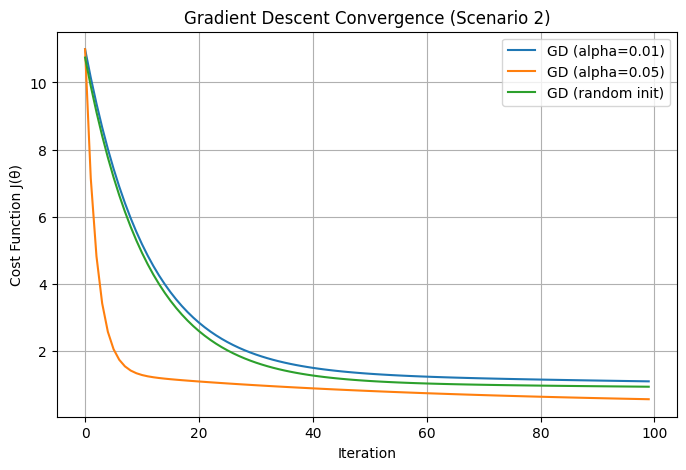

In [75]:
plt.figure(figsize=(8,5))

plt.plot(cost_gd1, label="GD (alpha=0.01)")
plt.plot(cost_gd2, label="GD (alpha=0.05)")
plt.plot(cost_gd3, label="GD (random init)")

plt.xlabel("Iteration")
plt.ylabel("Cost Function J(θ)")
plt.title("Gradient Descent Convergence (Scenario 2)")
plt.legend()
plt.grid(True)
plt.show()


In [76]:
print("Final Optimized Parameters:")
print("θ0 (bias):", theta_gd1[0])
print("θ1 (x1):", theta_gd1[1])
print("θ2 (x2):", theta_gd1[2])
print("θ3 (x3):", theta_gd1[3])
print("θ4 (x4):", theta_gd1[4])
print("θ5 (x5):", theta_gd1[5])


Final Optimized Parameters:
θ0 (bias): 1.3972358396090172
θ1 (x1): 0.88920953376379
θ2 (x2): 0.322909200800904
θ3 (x3): 0.5789452495634361
θ4 (x4): 1.0064531711975997
θ5 (x5): 0.5334679345318964


# **Newton's method **

Cost Function, Gradient, Hessian

In [77]:
def cost_function(theta, X, y):
    n = len(y)
    return (1/n) * np.sum((X @ theta - y)**2)


def gradient(theta, X, y):
    n = len(y)
    return (2/n) * X.T @ (X @ theta - y)


def hessian(X):
    n = X.shape[0]
    return (2/n) * X.T @ X


Newton’s Method Implementation

In [78]:
def newtons_method(X, y, theta_init, iterations):
    theta = theta_init.copy()
    cost_history = []

    H = hessian(X)
    H_inv = np.linalg.inv(H)

    for _ in range(iterations):
        cost_history.append(cost_function(theta, X, y))
        grad = gradient(theta, X, y)
        theta = theta - H_inv @ grad

    return theta, cost_history


Newton zero initialization

In [79]:
theta_init_1 = np.zeros(6)

theta_newton_1, cost_newton_1 = newtons_method(
    X_bias, y,
    theta_init=theta_init_1,
    iterations=5
)

print("Newton Solution (zero init):")
theta_newton_1


Newton Solution (zero init):


array([ 2.29605845,  1.33677982, -2.09394696,  0.5064107 ,  2.84556842,
       -1.14032593])

Newton Run random intialization

In [80]:
theta_init_2 = np.random.randn(6)

theta_newton_2, cost_newton_2 = newtons_method(
    X_bias, y,
    theta_init=theta_init_2,
    iterations=5
)

print("Newton Solution (random init):")
theta_newton_2


Newton Solution (random init):


array([ 2.29605845,  1.33677982, -2.09394696,  0.5064107 ,  2.84556842,
       -1.14032593])

newtons large intitializaiton

In [82]:
theta_init_3 = np.ones(6) * 10

theta_newton_3, cost_newton_3 = newtons_method(
    X_bias, y,
    theta_init=theta_init_3,
    iterations=5
)

print("Newton Solution (large init):")
theta_newton_3


Newton Solution (large init):


array([ 2.29605845,  1.33677982, -2.09394696,  0.5064107 ,  2.84556842,
       -1.14032593])

convergence plots

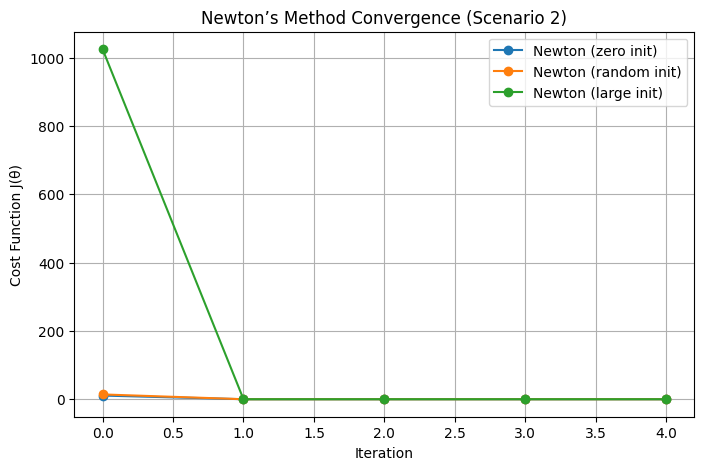

In [83]:
plt.figure(figsize=(8,5))

plt.plot(cost_newton_1, marker='o', label="Newton (zero init)")
plt.plot(cost_newton_2, marker='o', label="Newton (random init)")
plt.plot(cost_newton_3, marker='o', label="Newton (large init)")

plt.xlabel("Iteration")
plt.ylabel("Cost Function J(θ)")
plt.title("Newton’s Method Convergence (Scenario 2)")
plt.legend()
plt.grid(True)
plt.show()


final optimized parameters

In [84]:
print("Final Optimized Parameters (Newton’s Method):")
print("θ0 (bias):", theta_newton_1[0])
print("θ1:", theta_newton_1[1])
print("θ2:", theta_newton_1[2])
print("θ3:", theta_newton_1[3])
print("θ4:", theta_newton_1[4])
print("θ5:", theta_newton_1[5])


Final Optimized Parameters (Newton’s Method):
θ0 (bias): 2.2960584459778404
θ1: 1.336779816671169
θ2: -2.093946961341903
θ3: 0.5064106997705036
θ4: 2.8455684187804686
θ5: -1.1403259254066107


# ***scenario 3***

define obkective funciton

In [88]:
# Energy function
def E(v, h):
    return 0.1*v**2 + 0.2*h**2 - 2*v - 3*h + 25


Gradient and Hessian

In [89]:
H = np.array([
    [0.2, 0.0],
    [0.0, 0.4]
])

H_inv = np.linalg.inv(H)

GRADIENT DESCENT

gd small learinign rate

In [90]:
alpha = 0.05
iterations = 40

v, h = 0.0, 0.0
gd1_history = []

for _ in range(iterations):
    gd1_history.append(E(v, h))

    dv = 0.2*v - 2
    dh = 0.4*h - 3

    v = v - alpha * dv
    h = h - alpha * dh

print("GD Run 1 (alpha=0.05):")
print("v =", v, ", h =", h)
print("Energy =", E(v, h))


GD Run 1 (alpha=0.05):
v = 3.310282414303195 , h = 4.157246970367868
Energy = 10.46003170106107


gd large learning rate

In [91]:
alpha = 0.2
iterations = 40

v, h = 0.0, 0.0
gd2_history = []

for _ in range(iterations):
    gd2_history.append(E(v, h))

    dv = 0.2*v - 2
    dh = 0.4*h - 3

    v = v - alpha * dv
    h = h - alpha * dh

print("GD Run 2 (alpha=0.2):")
print("v =", v, ", h =", h)
print("Energy =", E(v, h))


GD Run 2 (alpha=0.2):
v = 8.0463384844468 , h = 7.232961206470954
Energy = 4.145941275185251


gd differnet initializaiotn

In [92]:
alpha = 0.1
iterations = 40

v, h = -10.0, 20.0
gd3_history = []

for _ in range(iterations):
    gd3_history.append(E(v, h))

    dv = 0.2*v - 2
    dh = 0.4*h - 3

    v = v - alpha * dv
    h = h - alpha * dh

print("GD Run 3 (different init):")
print("v =", v, ", h =", h)
print("Energy =", E(v, h))


GD Run 3 (different init):
v = 1.08599192098098 , h = 9.9420768944415
Energy = 12.888701914954645


# **newtons **

newtons 0 initializaiton

In [93]:
v, h = 0.0, 0.0
newton1_history = []

for _ in range(5):
    newton1_history.append(E(v, h))

    grad = np.array([0.2*v - 2, 0.4*h - 3])
    update = H_inv @ grad

    v = v - update[0]
    h = h - update[1]

print("Newton Run 1:")
print("v =", v, ", h =", h)
print("Energy =", E(v, h))


Newton Run 1:
v = 10.0 , h = 7.5
Energy = 3.75


newtons differnet initializaiton

In [94]:
v, h = -20.0, 15.0
newton2_history = []

for _ in range(5):
    newton2_history.append(E(v, h))

    grad = np.array([0.2*v - 2, 0.4*h - 3])
    update = H_inv @ grad

    v = v - update[0]
    h = h - update[1]

print("Newton Run 2:")
print("v =", v, ", h =", h)
print("Energy =", E(v, h))


Newton Run 2:
v = 10.0 , h = 7.5
Energy = 3.75


newtons large initializaiton

In [95]:
v, h = 50.0, -50.0
newton3_history = []

for _ in range(5):
    newton3_history.append(E(v, h))

    grad = np.array([0.2*v - 2, 0.4*h - 3])
    update = H_inv @ grad

    v = v - update[0]
    h = h - update[1]

print("Newton Run 3:")
print("v =", v, ", h =", h)
print("Energy =", E(v, h))


Newton Run 3:
v = 10.0 , h = 7.5
Energy = 3.75


convergence plots gradeints

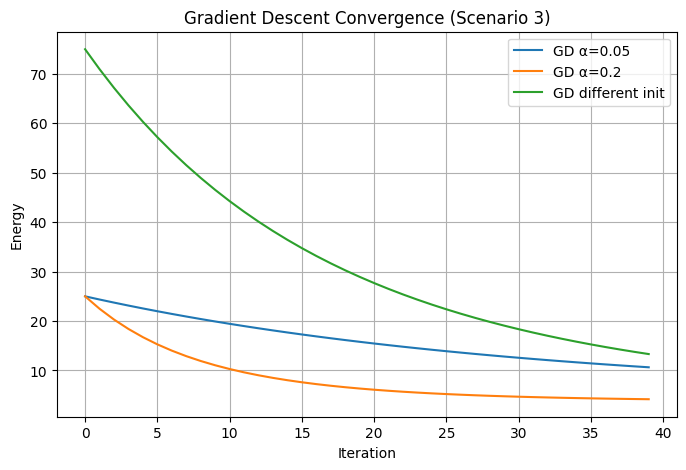

In [96]:
plt.figure(figsize=(8,5))
plt.plot(gd1_history, label="GD α=0.05")
plt.plot(gd2_history, label="GD α=0.2")
plt.plot(gd3_history, label="GD different init")

plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("Gradient Descent Convergence (Scenario 3)")
plt.legend()
plt.grid(True)
plt.show()


convegence plots newtons

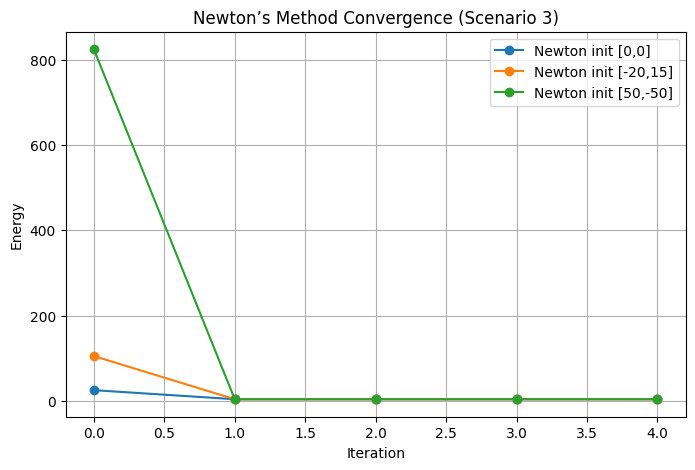

In [97]:
plt.figure(figsize=(8,5))
plt.plot(newton1_history, marker='o', label="Newton init [0,0]")
plt.plot(newton2_history, marker='o', label="Newton init [-20,15]")
plt.plot(newton3_history, marker='o', label="Newton init [50,-50]")

plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("Newton’s Method Convergence (Scenario 3)")
plt.legend()
plt.grid(True)
plt.show()
